<a href="https://colab.research.google.com/github/WattEfird4/DAX-Measures-Workflow/blob/main/Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[link text](https://)

# Project Architecture
### IT Incident Management Audit: Exploratory Data Analysis and Control Effectiveness Assessment Using Python and Power BI

### Business Problem

The Internal Audit team has been asked to evaluate whether the Incident Management process is operating effectively and whether incidents are:

Resolved within SLA
Assigned efficiently
Escalated appropriately
Closed effectively
Managed consistently across support groups

The audit will use data analytics to identify control weaknesses and operational risks.

### Project Phases

<b> Data Understanding</b> Synthetic source infrastructure via audit_dataset.csv.1

<b>Data Quality Assessment</b> (Python): Anomaly flagging, normalization, and relational mapping via clean_and_flag.py.1

<b>Exploratory Data Analysis</b>

<b>Visualization (Power BI)</b>:

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sqlite3

#1 Extract and Sanitize

df = pd.read_csv('/content/drive/MyDrive/incident_event_log.csv')

print(df.shape)
print(df.info())
print(df.describe(include='all'))

(119998, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119998 entries, 0 to 119997
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   119998 non-null  object
 1   incident_state           119998 non-null  object
 2   active                   119998 non-null  bool  
 3   reassignment_count       119998 non-null  int64 
 4   reopen_count             119998 non-null  int64 
 5   sys_mod_count            119998 non-null  int64 
 6   made_sla                 119998 non-null  bool  
 7   caller_id                119998 non-null  object
 8   opened_by                119998 non-null  object
 9   opened_at                119998 non-null  object
 10  sys_created_by           119998 non-null  object
 11  sys_created_at           119998 non-null  object
 12  sys_updated_by           119998 non-null  object
 13  sys_updated_at           119998 non-null  object
 14  contact

In [11]:
df['assignment_group'].value_counts()

,count
assignment_group,
Group 70,35023
?,14213
Group 25,6765
Group 24,5823
Group 20,5146
...,...
Group 79,9
Group 71,6
Group 80,6


In [10]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1VfooEbeT82Mka4bQXgvu88NT-RWkeR0qeU41iqBW-9Y/edit#gid=0


## Phase 2: Data Quality Assessment

Missing Values

In [12]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing.head(20)

,0
number,0
incident_state,0
active,0
reassignment_count,0
reopen_count,0
sys_mod_count,0
made_sla,0
caller_id,0
opened_by,0
opened_at,0


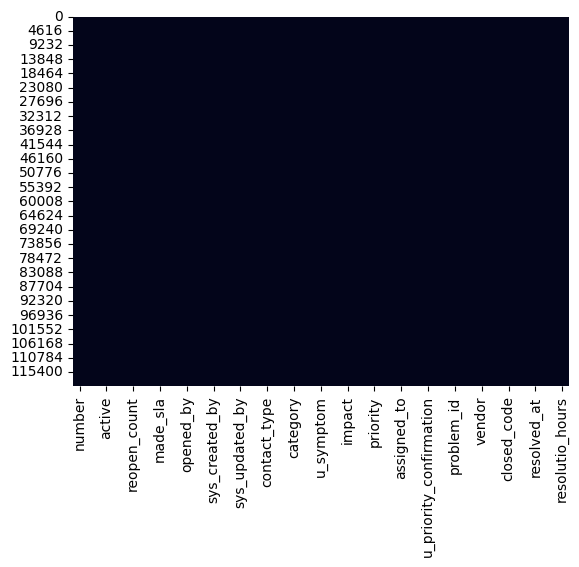

In [20]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [21]:
df.isnull().sum()

,0
number,0
incident_state,0
active,0
reassignment_count,0
reopen_count,0
sys_mod_count,0
made_sla,0
caller_id,0
opened_by,0
opened_at,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.columns

Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by',
       'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory',
       'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority',
       'assignment_group', 'assigned_to', 'knowledge',
       'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor',
       'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at',
       'resolution_hours', 'aging_bucket'],
      dtype='object')

In [36]:
df.nunique().sort_values(ascending=False)

,0
sys_updated_at,41969
number,20769
opened_at,16349
resolved_at,15333
resolution_hours,10015
sys_created_at,9980
caller_id,4829
closed_at,2013
sys_updated_by,714
u_symptom,500


The unique value analysis shows significant variation in feature cardinality across the dataset. Variables such as number, opened_at, and sys_updated_at contain nearly unique values for each record, while fields like priority, incident_state, and made_sla consist of a relatively small set of categories. As a result, high-cardinality variables may require specialized preprocessing techniques or encoding methods before being incorporated into machine learning models.

No duplicates and no missing values in dataset

## Phase 3: Feature Engineering

Incident Resolution Time

In [23]:
df['opened_at'] = pd.to_datetime(df['opened_at'], format='%d/%m/%Y %H:%M')
df['closed_at'] = pd.to_datetime(df['closed_at'], format='%d/%m/%Y %H:%M')

df['resolutio_hours'] = (
    df['closed_at'] - df['opened_at']
).dt.total_seconds() / 3600

In [27]:
df['resolution_hours'] = df['resolutio_hours']
df.columns

Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by',
       'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory',
       'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority',
       'assignment_group', 'assigned_to', 'knowledge',
       'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor',
       'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at',
       'resolutio_hours', 'resolution_hours'],
      dtype='object')

In [30]:
df[['resolution_hours', 'resolutio_hours']].head()

,resolution_hours,resolutio_hours
0,130.733333,130.733333
1,130.733333,130.733333
2,130.733333,130.733333
3,130.733333,130.733333
4,149.333333,149.333333


In [31]:
df.drop(columns=['resolutio_hours'], inplace=True, axis=1)

Resolution Buckets

In [32]:
bins = [0,24,72,168,729,99999]

labels = [
    '< 1 Day',
    '1-3 Days',
    '4-7 Days',
    '1-4 Weeks',
    '> 30 Days'
]

df['aging_bucket'] = pd.cut(
    df['resolution_hours'],
    bins=bins,
    labels=labels
)


# Phase 4 Exploratory Data Analysis

## EDA 1: Incident Volume by Category

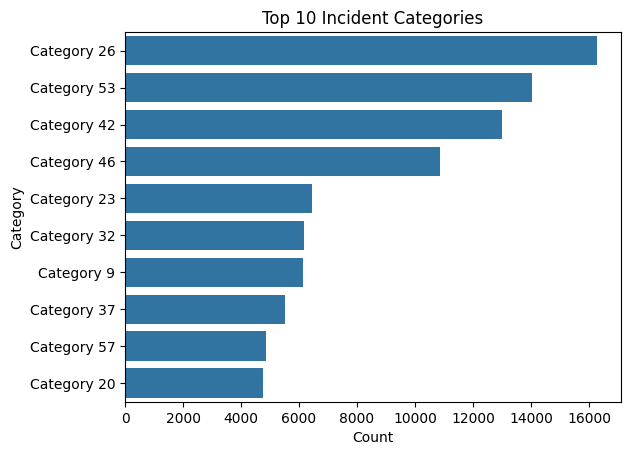

In [34]:
top_categories = (
    df['category']
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top 10 Incident Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

Incident Volume by Priority

<Axes: xlabel='priority', ylabel='count'>

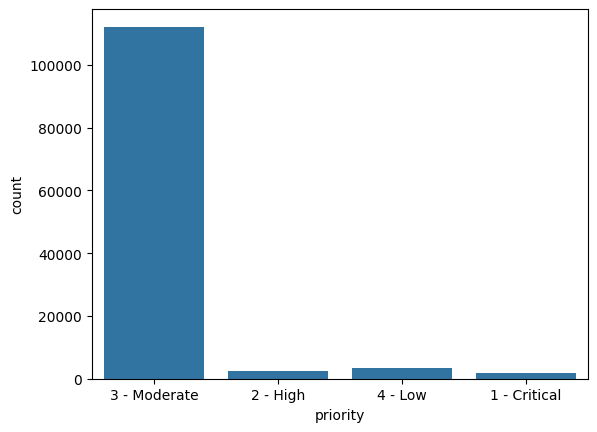

In [39]:
sns.countplot(
    data=df,
    x='priority'
)

Most incidents are moderate risk

SLA Compliance Distribution

<Axes: ylabel='count'>

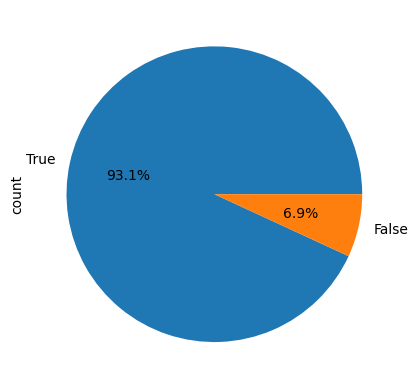

In [42]:
sla = (
    df['made_sla']
    .value_counts()
)

sla.plot(
    kind='pie',
    autopct='%1.1f%%' # Changed from '%1.1f%' to '%1.1f%%'
)

The organization is meetin 93.1% of its established service-level commitments

Reolution Time Distribution

<Axes: xlabel='resolution_hours', ylabel='Count'>

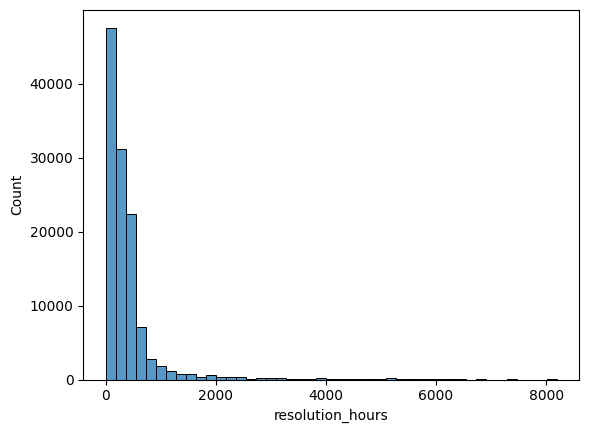

In [43]:
# hope to identify any operational bottlenecks with this visualization
sns.histplot(
    df['resolution_hours'],
    bins=45
)

<Axes: xlabel='resolution_hours'>

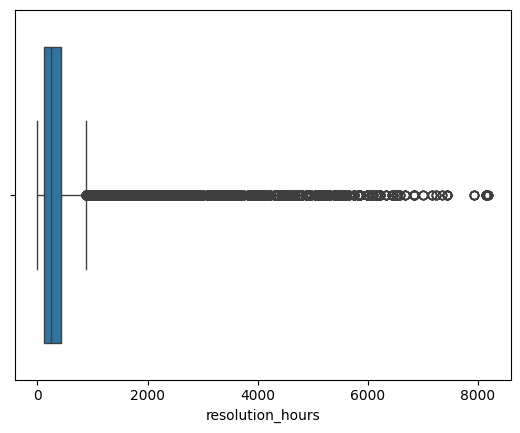

In [44]:
sns.boxplot(
    x=df['resolution_hours']
)

Reassignmet Analysis

<Axes: xlabel='reassignment_count', ylabel='Count'>

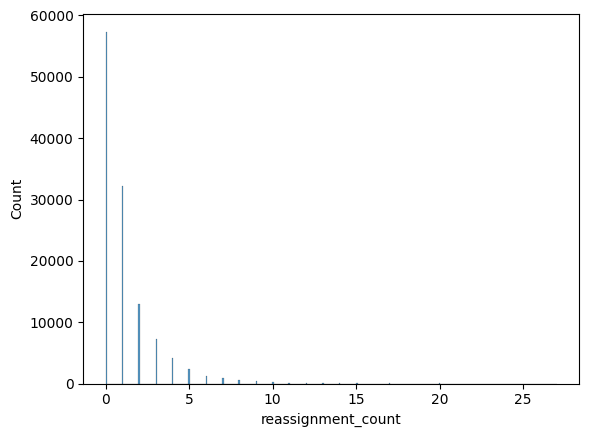

In [48]:
sns.histplot(
    df['reassignment_count']
)

Create Flag

In [51]:
df['reassignment_flag'] = (
    df['reassignment_count'] > 3
)

In [53]:
# Calculate
df['reassignment_flag'].mean()*100

np.float64(8.502641710695178)

EDA: Reopended Incident Analysis

<Axes: xlabel='reopen_count', ylabel='count'>

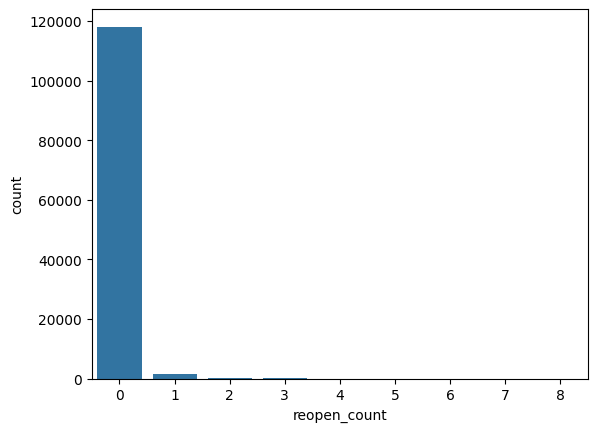

In [55]:
sns.countplot(
    x='reopen_count',
    data=df
)

In [56]:
# creating metrics
reopened_pct = (
    (df['reopen_count'] > 0)
    .mean()
) * 100

In [57]:
print(reopened_pct)

1.6283604726745444


Only 1.63% are being reopened

EDA 8: SLA Violations by Assigment Group

In [58]:
sla_group = pd.crosstab(
    df['assignment_group'],
    df['made_sla']
)

In [59]:
sla_group.sort_values(
    False,
    ascending=False
).head(20)

made_sla,False,True
assignment_group,,
Group 70,1378,33645
?,1115,13098
Group 25,618,6147
Group 39,366,3585
Group 24,337,5486
Group 23,318,3563
Group 10,251,1379
Group 73,249,2592
Group 28,239,2951


<Axes: xlabel='made_sla', ylabel='assignment_group'>

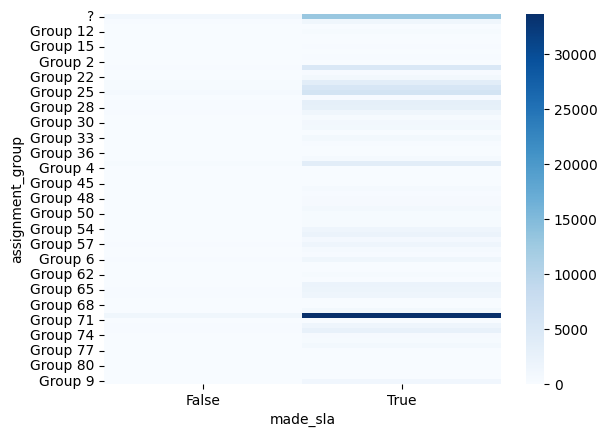

In [60]:
sns.heatmap(
    sla_group,
    cmap='Blues'
)

Group 71 and the ? group contribute most to SLA failures

Correlation Analysis

In [61]:
numeric_columns = [
    'reassignment_count',
    'reopen_count',
    'sys_mod_count',
    'resolution_hours'
]

corr = df[numeric_columns].corr()

<Axes: >

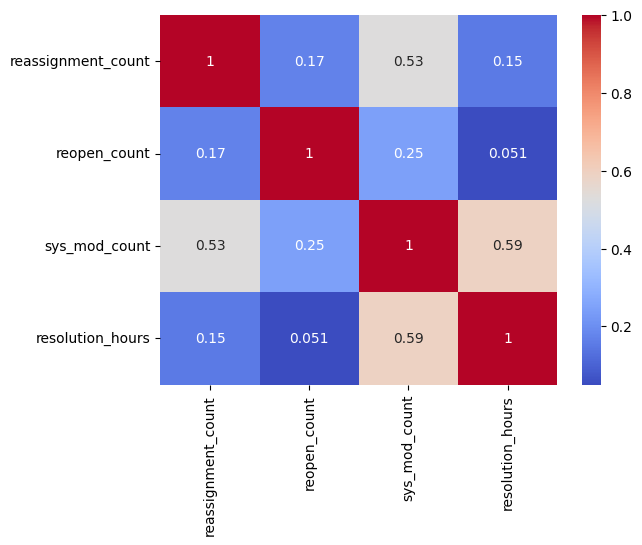

In [62]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

EDA 10 Time Series Analysis

/tmp/ipykernel_5424/3062747970.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


<Axes: xlabel='opened_at'>

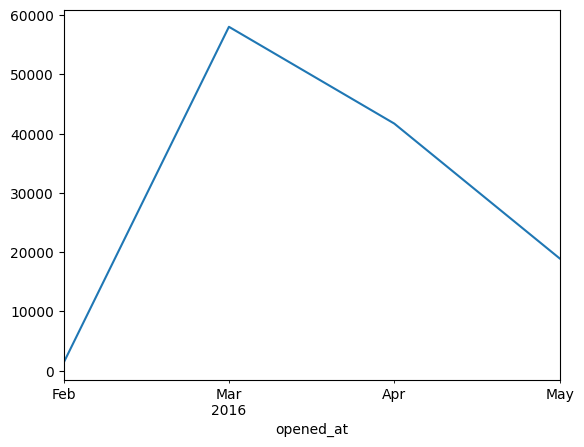

In [63]:
monthly = (
    df.
    groupby(
        pd.Grouper(
            key='opened_at',
            freq='M'
        )
    )
    .size()
)

monthly.plot()

/tmp/ipykernel_5424/1208514330.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


<Axes: xlabel='opened_at'>

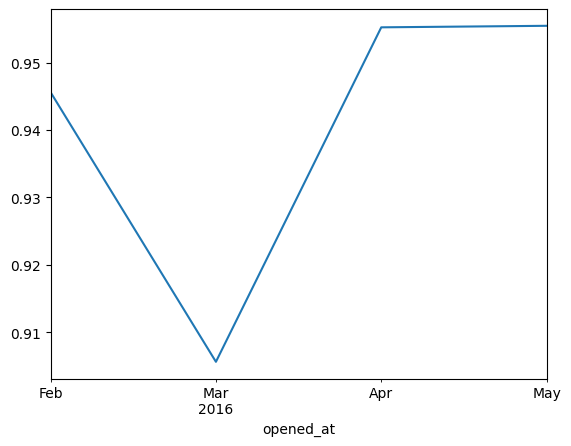

In [64]:
sla_monthly = (
    df
    .groupby(
        pd.Grouper(
            key='opened_at',
            freq='M'
        )
    )
    ['made_sla']
    .mean()
)

sla_monthly.plot()
#

Incident Aging Analysis

In [65]:
aging = (
    df['aging_bucket']
    .value_counts()
)

<Axes: xlabel='aging_bucket'>

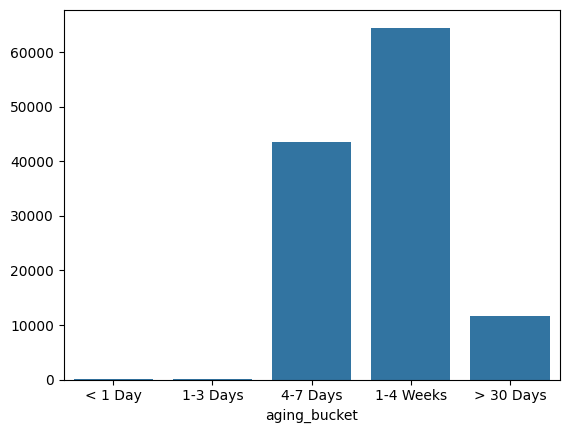

In [66]:
sns.barplot(
    x=aging.index,
    y=aging.values
)

Identifying incidents older the 30 days

In [67]:
aging30 = df[
    df['resolution_hours'] > 720
]

In [69]:
from scipy.stats import zscore

df['z_score'] = zscore(
    df['resolution_hours']
)

outliers = df[
    df['z_score'] > 3
]

print(outliers.shape)



(2675, 41)


Extremely long resolution times may indicate:

*Escalation failures*

*Resource shortages*

*Ineffective monitoring*

EDA Route Cause Analysis

Analyze:

Category
Priority
Assignment Group

for incidents that:

In [76]:
violations = df[df['made_sla'] == False]

In [77]:
category_violations_count = violations['category'].value_counts()
percentage_violations_by_category = (category_violations_count / len(violations)) * 100

print('Percentage of SLA Violations per Category:')
display(percentage_violations_by_category)

Percentage of SLA Violations per Category:


,count
category,
Category 46,13.147700
Category 26,11.840194
Category 53,11.198547
Category 42,7.723971
Category 23,5.290557
Category 45,5.108959
Category 9,4.927361
Category 61,4.782082
Category 37,4.443099


## SLA Violation Rate per Category

In [85]:
total_incidents_per_category = df['category'].value_counts()
sla_violations_per_category = violations['category'].value_counts()

# Calculate the percentage of SLA violations per category
violation_rate_category = (sla_violations_per_category / total_incidents_per_category) * 100

print('SLA Violation Rate per Category:')
display(violation_rate_category.sort_values(ascending=False).head(10))

SLA Violation Rate per Category:


,count
category,
Category 45,12.901253
Category 62,12.000000
Category 55,10.861423
Category 8,10.619469
Category 22,10.275689
Category 7,10.256410
Category 46,10.012908
Category 44,9.027778
Category 61,8.822872


## SLA Violation Rate per Assignment Group

In [90]:
total_incidents_per_assignment_group = df['assignment_group'].value_counts()
sla_violations_per_assignment_group = violations['assignment_group'].value_counts()

# Calculate the percentage of SLA violations per assignment group
violation_rate_assignment_group = (sla_violations_per_assignment_group / total_incidents_per_assignment_group) * 100

print('SLA Violation Rate per Assignment Group:')
display(violation_rate_assignment_group.sort_values(ascending=False).head(15))

SLA Violation Rate per Assignment Group:


,count
assignment_group,
Group 12,20.131291
Group 14,17.647059
Group 71,16.666667
Group 15,15.789474
Group 3,15.732759
Group 10,15.398773
Group 68,15.172414
Group 13,15.094340
Group 61,14.925373


/tmp/ipykernel_5424/4068621989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=violation_rate_assignment_group.sort_values(ascending=False).head(15).values,


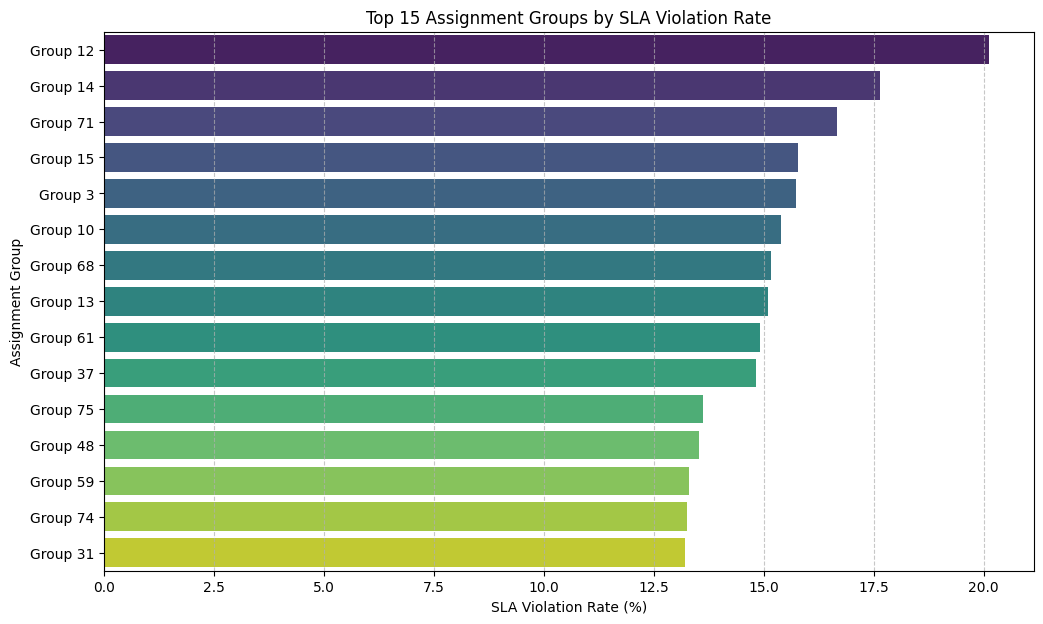

In [98]:
plt.figure(figsize=(12, 7))
sns.barplot(x=violation_rate_assignment_group.sort_values(ascending=False).head(15).values,
            y=violation_rate_assignment_group.sort_values(ascending=False).head(15).index,
            palette='viridis')
plt.title('Top 15 Assignment Groups by SLA Violation Rate')
plt.xlabel('SLA Violation Rate (%)')
plt.ylabel('Assignment Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Root Caue Anlysis
Analyze:

Category

Priority

Assignment Group

In [82]:
df['made_sla'] == False

,made_sla
0,False
1,False
2,False
3,False
4,False
...,...
119993,False
119994,False
119995,False
119996,False


<Axes: xlabel='count', ylabel='category'>

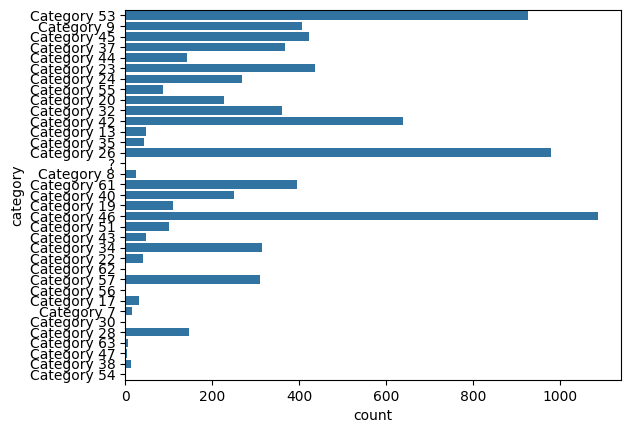

In [83]:
sns.countplot (
    data=violations,
    y='category'
)

<Axes: xlabel='count', ylabel='priority'>

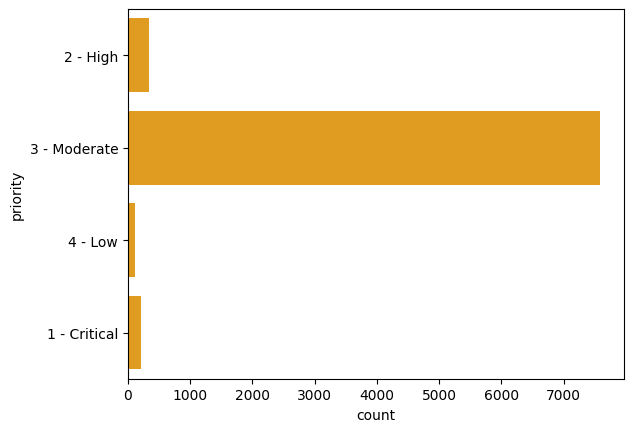

In [99]:
sns.countplot (
    data=violations,
    y='priority',
    color='orange'
)

<Axes: xlabel='count', ylabel='assignment_group'>

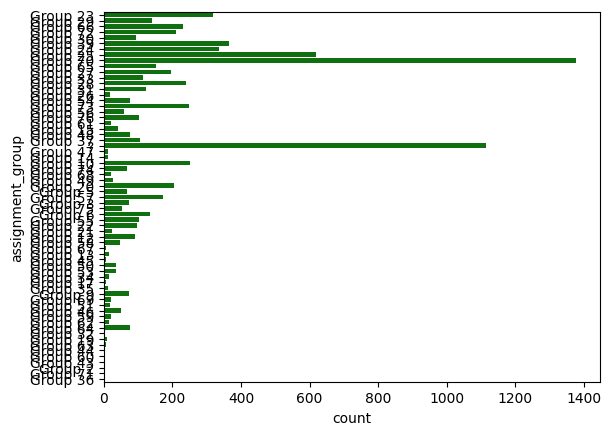

In [100]:
sns.countplot (
    data=violations,
    y='assignment_group',
    color='green'
)

Advanced Visualizations

Executive Dashboard Figures:
1. KPI_summarry_panel
2. SLA Compliance Donut Chart
3. Monthly Incident tred
4. Resoltion Time Instaggram
6. Priority Distribution

Additional Figures
1. Assignment Group Heatmap
2. Reassignment Distribution
3. Reopen Analysis
4. Aging Analysis
5. Correlation Matrix

Power BI Dashboard Structure
Page 1: Executive Summary

KPIs

Total Incidents
SLA Compliance %
Average Resolution Hours
Reopened %
Reassignment %
Page 2: Operational Performance

Charts

Monthly Incidents
Incident Categories
Priority Analysis
Location Analysis
Page 3: IT Audit Findings

Charts

SLA Exceptions
Aging Incidents
Reopened Incidents
Excessive Reassignments
Page 4: Risk Analytics

Charts

Resolution Time Outliers
Support Group Performance
Root Cause Analysis
Risk Heat Map


--- Assignment Group SLA Heatmap ---


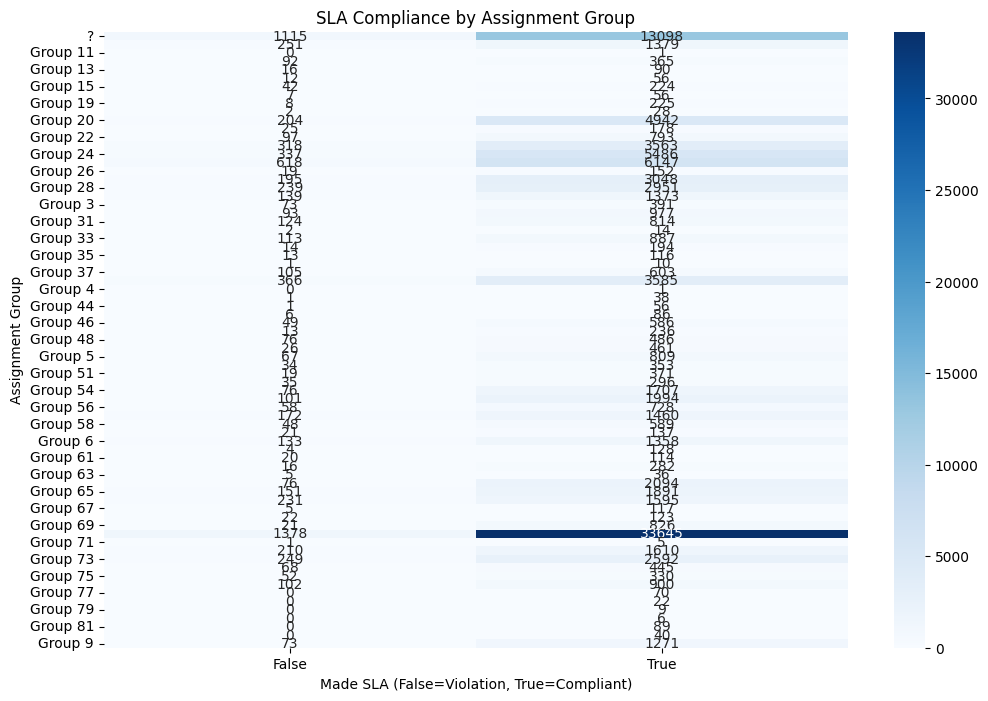


--- Reassignment Count Distribution ---


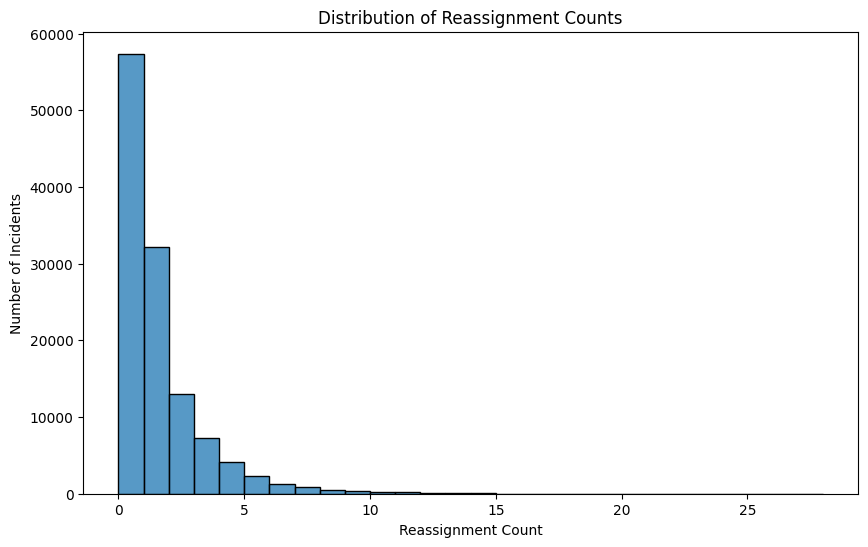


--- Reopen Count Analysis ---


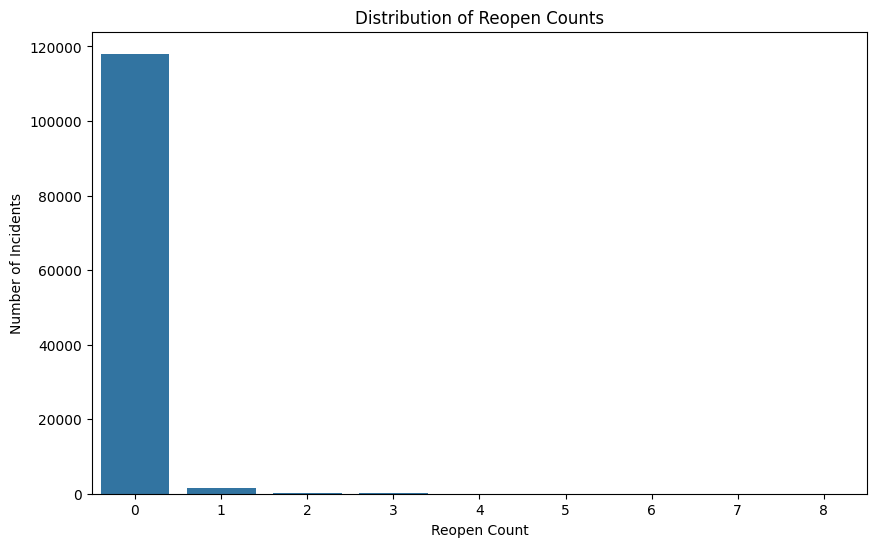


--- Monthly Incident Volume Trend ---


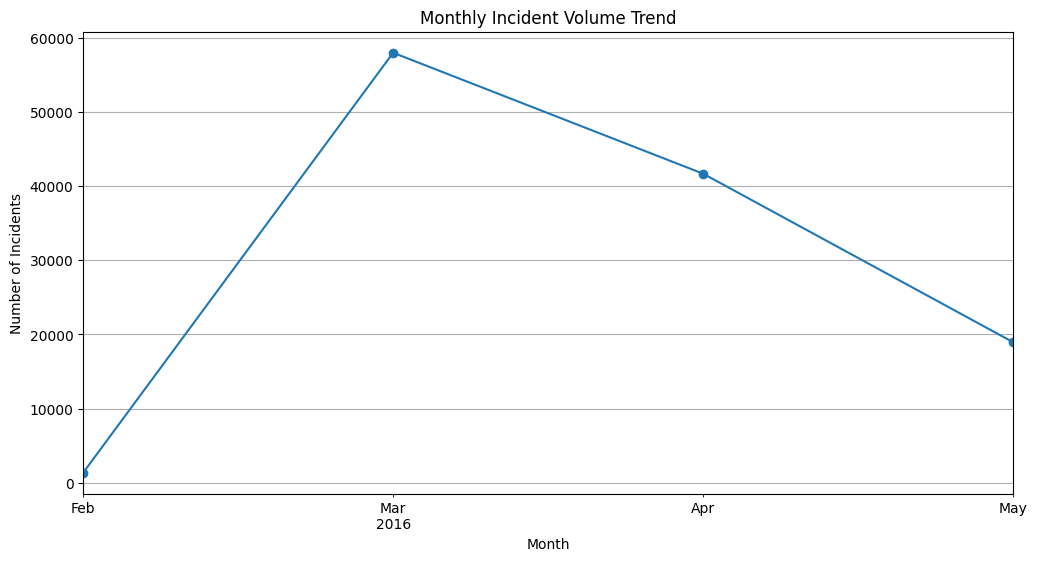

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Assignment Group Heatmap
print("\n--- Assignment Group SLA Heatmap ---")
sla_group = pd.crosstab(df['assignment_group'], df['made_sla'])
plt.figure(figsize=(12, 8))
sns.heatmap(sla_group, cmap='Blues', annot=True, fmt='d')
plt.title('SLA Compliance by Assignment Group')
plt.xlabel('Made SLA (False=Violation, True=Compliant)')
plt.ylabel('Assignment Group')
plt.show()

# 2. Reassignment Distribution Visual
print("\n--- Reassignment Count Distribution ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['reassignment_count'], bins=range(int(df['reassignment_count'].max()) + 2), kde=False)
plt.title('Distribution of Reassignment Counts')
plt.xlabel('Reassignment Count')
plt.ylabel('Number of Incidents')
plt.show()

# 3. Reopen Analysis
print("\n--- Reopen Count Analysis ---")
plt.figure(figsize=(10, 6))
sns.countplot(x='reopen_count', data=df)
plt.title('Distribution of Reopen Counts')
plt.xlabel('Reopen Count')
plt.ylabel('Number of Incidents')
plt.show()

# 4. Monthly Incident Trend
print("\n--- Monthly Incident Volume Trend ---")
plt.figure(figsize=(12, 6))
monthly = df.groupby(pd.Grouper(key='opened_at', freq='ME')).size()
monthly.plot(kind='line', marker='o')
plt.title('Monthly Incident Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.show()

In [94]:
df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,caused_by,closed_code,resolved_by,resolved_at,closed_at,resolution_hours,aging_bucket,reassignmet_flag,reassignment_flag,z_score
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,?,code 5,Resolved by 149,29/2/2016 11:29,2016-03-05 12:00:00,130.733333,4-7 Days,False,False,-0.439921
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,?,code 5,Resolved by 149,29/2/2016 11:29,2016-03-05 12:00:00,130.733333,4-7 Days,False,False,-0.439921
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,?,code 5,Resolved by 149,29/2/2016 11:29,2016-03-05 12:00:00,130.733333,4-7 Days,False,False,-0.439921
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,?,code 5,Resolved by 149,29/2/2016 11:29,2016-03-05 12:00:00,130.733333,4-7 Days,False,False,-0.439921
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,?,code 5,Resolved by 81,1/3/2016 09:52,2016-03-06 10:00:00,149.333333,4-7 Days,False,False,-0.412022


In [95]:
df['resolved_by'].value_counts()

,count
resolved_by,
Resolved by 15,14398
Resolved by 11,9864
Resolved by 53,3381
Resolved by 177,3226
Resolved by 62,3186
...,...
Resolved by 201,5
Resolved by 228,4
Resolved by 48,3


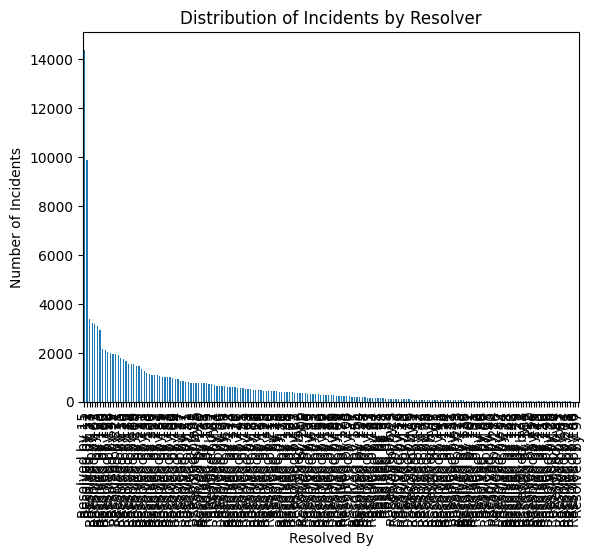

In [97]:
df['resolved_by'].visualize()